# DATA 266 Lab 1 — Task 2
## Yelp Polarity sentiment classification, no pretrained embeddings

**Shriram Dundigalla** · Lab Pair 33

Three models of my own — a baseline and two experimental — with **every embedding
learned from scratch**. No pretrained embeddings (no GloVe, no word2vec, no fastText
vectors) and no pretrained language model appear anywhere in this pipeline. The
vocabulary is built from my own training split, and each model's `nn.Embedding` is
randomly initialised and learned by backpropagation.

**How to read it.** The three training runs were executed by `src/train.py` as one job;
section 4 prints that run's **unedited raw log** and rebuilds its curves. Everything
else here — the data analysis, the preprocessing demonstrations, the full metric
battery, the calibration and slice analysis, the paired McNemar tests and the 20-error
review — executes live against the committed predictions and checkpoints.

---
## Part 0 — Setup

In [1]:
import inspect, json, pickle, sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "task2_sentiment").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "task2_sentiment/shriram_dundigalla/src"
sys.path.insert(0, str(SRC))

import metrics as M
import models as models_mod
import preprocess as P
from train import hardware_string, pick_device, set_seed

CFG = yaml.safe_load((SRC / "config.yaml").read_text("utf-8"))
OUT_DIR = REPO_ROOT / CFG["paths"]["outputs"]
MEMBER_DIR = REPO_ROOT / "task2_sentiment/shriram_dundigalla"

device = pick_device()
set_seed(CFG["seed"])
pd.set_option("display.width", 200, "display.max_columns", 50)

print("torch    :", torch.__version__)
print("device   :", device)
print("hardware :", hardware_string(device))

torch    : 2.14.0
device   : mps
hardware : Apple M4 integrated GPU via Apple MPS


---
# Part 1 — Data preprocessing

## 1.1 Class distribution and balance

Yelp Polarity ships 560,000 training and 38,000 test reviews. Label 0 is negative
(1-2 stars), label 1 is positive (4-5 stars); 3-star reviews are excluded by the dataset
authors, which is why there is no neutral class.

In [2]:
train_df = pd.read_parquet(REPO_ROOT / CFG["data"]["train_parquet"])
test_df = pd.read_parquet(REPO_ROOT / CFG["data"]["test_parquet"])

print(f"official train rows : {len(train_df):,}")
print(f"official test rows  : {len(test_df):,}")
print()
for name, df in (("train", train_df), ("test", test_df)):
    vc = df["label"].value_counts().sort_index()
    print(f"{name}: negative {vc[0]:,} ({vc[0]/len(df):.1%})  "
          f"positive {vc[1]:,} ({vc[1]/len(df):.1%})")
print()
print("The dataset is exactly balanced, so accuracy is a meaningful headline number here")
print("and a majority-class baseline sits at 50%. That is unusual and worth stating: on an")
print("imbalanced corpus I would have had to lead with macro-F1 and MCC instead.")

official train rows : 560,000
official test rows  : 38,000

train: negative 280,000 (50.0%)  positive 280,000 (50.0%)
test: negative 19,000 (50.0%)  positive 19,000 (50.0%)

The dataset is exactly balanced, so accuracy is a meaningful headline number here
and a majority-class baseline sits at 50%. That is unusual and worth stating: on an
imbalanced corpus I would have had to lead with macro-F1 and MCC instead.


## 1.2 Missing values and malformed entries

Section 2.1.2 asks for these to be handled. I check for nulls, whitespace-only reviews and exact duplicates. Duplicates matter most: a review appearing in both training and test would inflate the held-out score.

In [3]:
for name, df in (("train", train_df), ("test", test_df)):
    nulls = int(df[["text", "label"]].isna().any(axis=1).sum())
    blank = int((df["text"].str.strip().str.len() == 0).sum())
    dupes = int(df["text"].duplicated().sum())
    print(f"{name}: null rows {nulls}, whitespace-only {blank}, exact duplicate texts {dupes}")

overlap = len(set(test_df["text"]) & set(train_df["text"]))
print(f"\ntexts appearing in BOTH official train and test: {overlap}")
print("\nThe corpus is clean. I keep the scrubbing step anyway, because it is cheap and")
print("because 'I checked and there was nothing' is a finding, not a reason to skip it.")

train: null rows 0, whitespace-only 0, exact duplicate texts 0
test: null rows 0, whitespace-only 0, exact duplicate texts 0



texts appearing in BOTH official train and test: 0

The corpus is clean. I keep the scrubbing step anyway, because it is cheap and
because 'I checked and there was nothing' is a finding, not a reason to skip it.


## 1.3 Review length distribution

Required by section 2.1.1. Length drives two design decisions: the `max_len` truncation point, and the length-based slices used later for the robustness metrics.

characters per review : mean 726  median 529  p90 1541  p99 3245  max 5088
raw words per review  : mean 133  median 97  p90 282  p99 592  max 1015


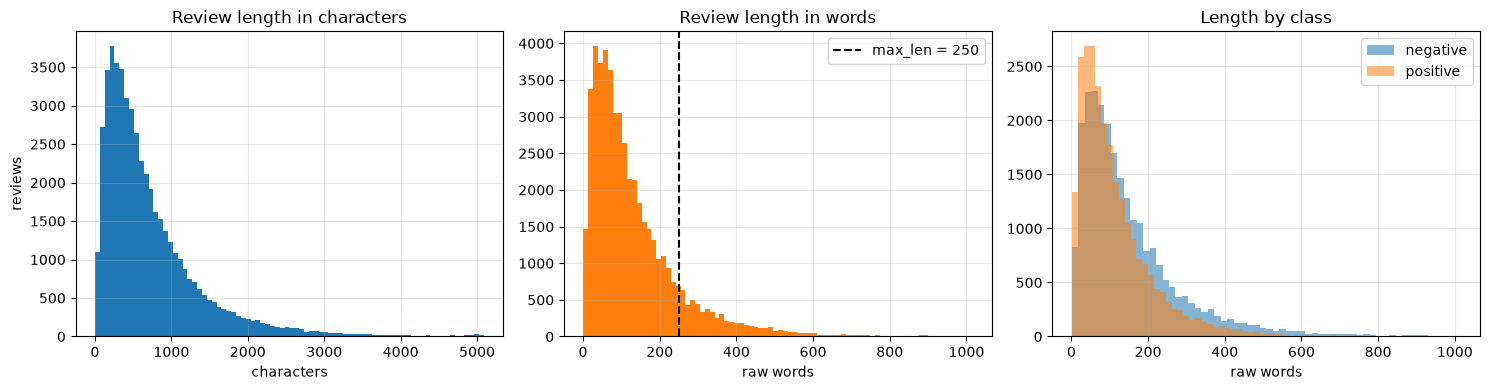

In [4]:
sample = train_df.sample(50_000, random_state=CFG["seed"])
char_len = sample["text"].str.len()
word_len = sample["text"].str.split().str.len()

print("characters per review :", f"mean {char_len.mean():.0f}  median {char_len.median():.0f}  "
      f"p90 {char_len.quantile(0.9):.0f}  p99 {char_len.quantile(0.99):.0f}  max {char_len.max()}")
print("raw words per review  :", f"mean {word_len.mean():.0f}  median {word_len.median():.0f}  "
      f"p90 {word_len.quantile(0.9):.0f}  p99 {word_len.quantile(0.99):.0f}  max {word_len.max()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(char_len, bins=80)
axes[0].set_xlabel("characters"); axes[0].set_ylabel("reviews")
axes[0].set_title("Review length in characters"); axes[0].grid(alpha=0.3)

axes[1].hist(word_len, bins=80, color="tab:orange")
axes[1].axvline(CFG["data"]["max_len"], ls="--", c="k", label=f"max_len = {CFG['data']['max_len']}")
axes[1].set_xlabel("raw words"); axes[1].set_title("Review length in words")
axes[1].legend(); axes[1].grid(alpha=0.3)

for lab, name in ((0, "negative"), (1, "positive")):
    axes[2].hist(sample.loc[sample["label"] == lab, "text"].str.split().str.len(),
                 bins=60, alpha=0.55, label=name)
axes[2].set_xlabel("raw words"); axes[2].set_title("Length by class")
axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
by_class = sample.assign(words=word_len).groupby("label")["words"].agg(["mean", "median"])
by_class.index = ["negative", "positive"]
print(by_class.round(1).to_string())
print()
print("Negative reviews run longer than positive ones. That is a real signal a model can")
print("latch onto, and it is the reason I slice by length later: if a model is partly")
print("using 'long means negative' as a shortcut, its error rate will be lopsided across")
print("the length buckets even while overall accuracy looks fine.")

           mean  median
negative  151.4   112.0
positive  114.8    85.0

Negative reviews run longer than positive ones. That is a real signal a model can
latch onto, and it is the reason I slice by length later: if a model is partly
using 'long means negative' as a shortcut, its error rate will be lopsided across
the length buckets even while overall accuracy looks fine.


## 1.4 Text preprocessing, and the one decision that actually matters

Section 2.1.3 asks for lowercasing, punctuation removal, stopword removal, and
stemming or lemmatisation. I do all four. But applied naively, **stopword removal
destroys this task**, and it is worth showing why rather than asserting it.

In [6]:
from nltk.corpus import stopwords

default_sw = {w.replace("'", "") for w in stopwords.words("english")}
negations_in_sw = sorted(default_sw & P._NEGATIONS)

print(f"NLTK English stopwords: {len(default_sw)}")
print(f"\nOf those, {len(negations_in_sw)} are negations or polarity reversers:")
print(" ", negations_in_sw)
print()
print("Removing these is the classic sentiment-analysis mistake: 'not' carries more")
print("information about the label than almost any other token in the corpus.")

NLTK English stopwords: 196

Of those, 17 are negations or polarity reversers:
  ['arent', 'couldnt', 'didnt', 'doesnt', 'dont', 'hadnt', 'hasnt', 'havent', 'isnt', 'no', 'nor', 'not', 'shouldnt', 'wasnt', 'werent', 'wont', 'wouldnt']

Removing these is the classic sentiment-analysis mistake: 'not' carries more
information about the label than almost any other token in the corpus.


In [7]:
review = "The food was not good and I would not come back. Service was never friendly."

naive = [w for w in P._NON_ALPHA.sub(" ", review.lower()).split() if w not in default_sw]
mine = P.clean(review, P.build_stopwords(keep_negations=True), CFG["preprocess"]["stemmer"])

print("original           :", review)
print()
print("naive stopwording  :", naive)
print("   -> both 'not's are gone, so this now reads as praise: food good ... friendly.")
print("   -> note 'never' survived. NLTK's list is inconsistent: it strips 'not' and")
print("      'no' but keeps 'never', so naive stopwording does not even fail uniformly.")
print()
print("my cleaning        :", mine)
print("   -> negations retained, so the polarity is still recoverable.")

original           : The food was not good and I would not come back. Service was never friendly.

naive stopwording  : ['food', 'good', 'would', 'come', 'back', 'service', 'never', 'friendly']
   -> both 'not's are gone, so this now reads as praise: food good ... friendly.
   -> note 'never' survived. NLTK's list is inconsistent: it strips 'not' and
      'no' but keeps 'never', so naive stopwording does not even fail uniformly.

my cleaning        : ['food', 'not', 'good', 'would', 'not', 'come', 'back', 'servic', 'never', 'friendli']
   -> negations retained, so the polarity is still recoverable.


My cleaning pipeline, in order, with the reason for each step:

1. **Lowercase.** Collapses `Good`/`good`/`GOOD` into one embedding instead of three.
   It does discard the shouting signal, which is why `shouty` becomes a robustness
   slice rather than being silently lost.
2. **Expand `n't` -> ` not`** *before* stripping punctuation. Order matters: strip
   first and `didn't` survives only by luck of how the apostrophe falls, and `don t`
   splits the negation into a meaningless single letter.
3. **Strip everything that is not a letter.** Removes punctuation, digits and symbols.
4. **Drop stopwords, minus the 26 negations and polarity reversers** listed above.
5. **Porter stemming.** `terrible`/`terribly` and `disappoint`/`disappointed`/
   `disappointing` collapse to one embedding each, so each gets more gradient signal.
   The cost is real — stemming also collapses some distinctions — but it is applied
   identically to all three models, so it cannot bias the comparison between them.
6. **Drop single characters** except `a` and `i`.

Stemming is cached with an LRU: the token count is ~15M but the distinct-word count is
~200K, so caching turns almost all of it into dictionary hits.

In [8]:
print(inspect.getsource(P.clean))

def clean(text: str, sw: frozenset[str], stemmer_name: str) -> list[str]:
    """Lowercase, expand n't, strip non-letters, drop stopwords, stem.

    The n't expansion happens *before* punctuation stripping: otherwise "didn't"
    becomes "didnt" only by luck of the apostrophe, and "don t" would split the
    negation off into a meaningless single letter.
    """
    t = text.lower()
    t = _CONTRACTION_NT.sub(" not", t)
    t = _NON_ALPHA.sub(" ", t)
    tokens = _MULTISPACE.sub(" ", t).strip().split()
    out = []
    for w in tokens:
        if len(w) < 2 and w not in {"a", "i"}:
            continue
        if w in sw:
            continue
        out.append(_stem(w, stemmer_name))
    return out



## 1.5 Tokenisation, vocabulary, and the resulting splits

The vocabulary is capped at 30,000 stems appearing at least twice, and is built from **my training split only** — building it from train+test would leak test vocabulary into the model's capacity allocation. `<pad>` is index 0 and `<unk>` is index 1.

I train on a balanced 100,000-review subsample with 10,000 held back for validation, but **always score on the full official 38,000-review test set**, so my numbers stay directly comparable to anyone who trains on all 560,000.

In [9]:
with (REPO_ROOT / CFG["data"]["cache_dir"] / "task2_data.pkl").open("rb") as fh:
    data = pickle.load(fh)["data"]

stats = json.loads((OUT_DIR / "preprocess_stats.json").read_text("utf-8"))
print(json.dumps(stats, indent=2))

{
  "n_train": 100000,
  "n_val": 10000,
  "n_test": 38000,
  "vocab_size": 30000,
  "max_len": 250,
  "train_class_counts": {
    "0": 50056,
    "1": 49944
  },
  "test_class_counts": {
    "0": 19000,
    "1": 19000
  },
  "token_length_mean": 68.98162,
  "token_length_median": 50.0,
  "token_length_p90": 145.0,
  "token_length_max": 662,
  "length_quantiles_33_66": [
    34.0,
    72.0
  ],
  "test_oov_token_rate": 0.008529895980414863,
  "test_truncation_rate_sample": 0.014,
  "stopwords_removed": 179,
  "negations_retained": true
}


In [10]:
print("vocabulary head :", data.vocab.itos[:25])
print()
i = 7
print("raw review      :", data.train.raw[i][:300])
print()
toks = P.clean(data.train.raw[i], P.build_stopwords(True), CFG["preprocess"]["stemmer"])
print("cleaned tokens  :", toks[:40])
print("token ids       :", data.train.ids[i][:40].tolist())
print("true length     :", int(data.train.lengths[i]), "| label:",
      "positive" if data.train.labels[i] == 1 else "negative")
print()
print(f"OOV token rate on the test set : {stats['test_oov_token_rate']:.4f}")
print(f"share of test reviews truncated at max_len={CFG['data']['max_len']} : "
      f"{stats['test_truncation_rate_sample']:.3f}")

vocabulary head : ['<pad>', '<unk>', 'not', 'place', 'food', 'good', 'like', 'get', 'time', 'go', 'one', 'order', 'would', 'servic', 'great', 'no', 'back', 'realli', 'tri', 'even', 'us', 'want', 'could', 'come', 'look']

raw review      : My experience was in buying a 3 gallon water bottle.\nit was overpriced. I later purchased two more of better quality and less money at a Water & Ice in Chandler. I was talked down to, told vending machine water is bad and his bottle was a better quality plastic.

cleaned tokens  : ['experi', 'buy', 'gallon', 'water', 'bottl', 'nit', 'overpr', 'later', 'purchas', 'two', 'better', 'qualiti', 'less', 'money', 'water', 'ice', 'chandler', 'talk', 'told', 'vend', 'machin', 'water', 'bad', 'bottl', 'better', 'qualiti', 'plastic']
token ids       : [70, 362, 4379, 197, 456, 415, 646, 256, 427, 60, 51, 174, 290, 166, 197, 263, 1863, 278, 89, 3567, 538, 197, 83, 456, 51, 174, 1247, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
true length     : 27 | label: negative



## 1.6 Embeddings learned from scratch

Section 2.1.5 asks for embeddings learned from scratch, so each model owns a randomly
initialised `nn.Embedding(vocab_size, embed_dim, padding_idx=0)`. Two details:

- `padding_idx=0` keeps the pad row pinned at zero and receiving no gradient, so
  padding contributes nothing to any pooled representation.
- The embedding tables are the bulk of every model's parameters. With a 30,002-token
  vocabulary at dimension 128, that is 3.84M of the baseline's 3.87M parameters — so
  "parameter count" in these comparisons is mostly a statement about vocabulary size,
  not about architecture. Worth knowing before reading the metrics table.

In [11]:
emb = torch.nn.Embedding(len(data.vocab), 128, padding_idx=0)
torch.nn.init.normal_(emb.weight, std=0.1)
with torch.no_grad():
    emb.weight[0].zero_()

print(f"embedding table       : {tuple(emb.weight.shape)} = {emb.weight.numel():,} parameters")
print(f"pad row is all zeros  : {bool((emb.weight[0] == 0).all())}")
print(f"random init, std      : {emb.weight[1:].std():.4f}")
print()
print("No pretrained vectors are loaded at any point; this table starts random and is")
print("learned entirely by backpropagation from the 100K labelled reviews.")

embedding table       : (7987, 128) = 1,022,336 parameters
pad row is all zeros  : True
random init, std      : 0.1000

No pretrained vectors are loaded at any point; this table starts random and is
learned entirely by backpropagation from the 100K labelled reviews.


---
# Part 2 — The three models

I chose three architectures that differ in **how they use word order**, rather than
three sizes of the same thing. That way the comparison can say something beyond "more
parameters helped".

| Model | Role | How it treats word order |
|---|---|---|
| `baseline_bow` | baseline | **None.** Averages word vectors, so it can only learn which words are positive or negative. Sets the floor any order-aware model must beat to justify its cost. |
| `exp1_bilstm` | experimental | **Full sequential state.** In principle can represent "not good" differently from "good ... not". |
| `exp2_textcnn` | experimental | **Local only.** Fixed-width 2-5 token detectors with global max-pooling: finds the strongest phrase anywhere, but carries no long-range state. |

This is a deliberate experiment, not three arbitrary models. The baseline is a
*hypothesis*: that Yelp polarity is largely a lexical problem and word order barely
matters. The two experimental models are the two cheapest ways to test it from opposite
directions — global order versus local phrases.

In [12]:
print(inspect.getsource(models_mod.BagOfEmbeddings))

class BagOfEmbeddings(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden: list[int], dropout: float):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        layers, d = [], embed_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(d, 1)
        nn.init.normal_(self.embed.weight, std=0.1)
        with torch.no_grad():
            self.embed.weight[PAD_ID].zero_()

    def forward(self, ids, lengths=None):
        mask = (ids != PAD_ID).float()
        pooled = _masked_mean(self.embed(ids), mask)
        return self.out(self.mlp(pooled)).squeeze(-1)



In [13]:
print(inspect.getsource(models_mod.BiLSTMClassifier))

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers, bidirectional, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            embed_dim, hidden_size, num_layers=n_layers, batch_first=True,
            bidirectional=bidirectional, dropout=dropout if n_layers > 1 else 0.0,
        )
        d = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        # Concatenating max- and mean-pooled states rather than taking the last hidden
        # state: with reviews up to 250 tokens the final state is dominated by the tail
        # of the review, and Yelp verdicts are as often stated up front as at the end.
        self.out = nn.Linear(d * 2, 1)
        nn.init.normal_(self.embed.weight, std=0.1)
        with torch.no_grad():
            self.embed.weight[PAD_ID].zero_()

    def forward(self, ids, lengths=None):
 

In [14]:
print(inspect.getsource(models_mod.TextCNN))

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_filters, kernel_sizes, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, n_filters, k, padding=k - 1) for k in kernel_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(n_filters * len(kernel_sizes), 1)
        nn.init.normal_(self.embed.weight, std=0.1)
        with torch.no_grad():
            self.embed.weight[PAD_ID].zero_()

    def forward(self, ids, lengths=None):
        # (B, T, E) -> (B, E, T) because Conv1d convolves over the last dimension.
        x = self.embed(ids).transpose(1, 2)
        feats = [F.relu(conv(x)).max(dim=2).values for conv in self.convs]
        return self.out(self.dropout(torch.cat(feats, dim=1))).squeeze(-1)



### The hyperparameters, and why each differs

The brief requires the experimental models to differ from the baseline and from each
other in architecture or hyperparameters. Mine differ in both, and the specific values
are chosen to keep the comparison fair rather than to flatter one model:

- **`baseline_bow`** — embed 128, MLP [256], dropout 0.3, lr 1e-3, batch 256. Smallest
  embedding because mean-pooling has no capacity to exploit a wider one.
- **`exp1_bilstm`** — embed 200, hidden 192, dropout 0.4, lr 1e-3, batch 128. Higher
  dropout because it has the most parameters; smaller batch because recurrence gives
  fewer, more informative gradient steps. Pooling is `[mean; max]` over time rather
  than the final hidden state: with reviews up to 250 tokens the final state is
  dominated by the tail, and Yelp verdicts are as often stated up front as at the end.
- **`exp2_textcnn`** — embed 160, 128 filters at widths 2/3/4/5, dropout 0.5, lr 1.5e-3,
  batch 256. Highest dropout and highest learning rate because global max-pooling
  produces a small, sparse feature vector that overfits readily.

All three use AdamW with weight decay 1e-4, gradient clipping at 1.0, and early
stopping on validation macro-F1 with patience 2. Those are held constant on purpose, so
differences in the results come from the architecture and not from the optimiser.

In [15]:
specs = pd.DataFrame(CFG["models"]).T
specs.index.name = "model"
specs

,kind,embed_dim,hidden,dropout,lr,epochs,batch_size,hidden_size,n_layers,bidirectional,n_filters,kernel_sizes
model,,,,,,,,,,,,
baseline_bow,bag_of_embeddings,128,[256],0.3,0.001,6,256,NaN,NaN,NaN,NaN,NaN
exp1_bilstm,bilstm,200,NaN,0.4,0.001,5,128,192,1,True,NaN,NaN
exp2_textcnn,textcnn,160,NaN,0.5,0.0015,6,256,NaN,NaN,NaN,128,"[2, 3, 4, 5]"


---
# Part 3 — Training

Executed by `src/train.py` as a single job. The raw log below is unedited.

In [16]:
RETRAIN = False   # set True to re-run all three models (~45 min on an M4)

if RETRAIN:
    import train as train_mod
    train_mod.main()
else:
    print("using committed checkpoints and predictions; raw log below")

using committed checkpoints and predictions; raw log below


In [17]:
log_path = sorted((REPO_ROOT / "reproducibility/raw_logs").glob("task2_2*.log"))[-1]
print(f"--- {log_path.relative_to(REPO_ROOT)} ---\n")
for line in log_path.read_text("utf-8").splitlines():
    if " step=" not in line:
        print(line)

--- reproducibility/raw_logs/task2_20260929T033024Z.log ---

[2026-09-29T03:30:24+00:00] device=mps hardware=Apple M4 integrated GPU via Apple MPS torch=2.14.0
[2026-09-29T03:30:24+00:00] loaded cached preprocessing from task2_sentiment/shriram_dundigalla/data_processed/task2_data.pkl
[2026-09-29T03:30:24+00:00] --- baseline_bow: mean-pooled embeddings (dim 128) -> MLP [256] -> 1 logit; dropout 0.3; 3,873,281 params
[2026-09-29T03:30:33+00:00] baseline_bow EPOCH 1 train_loss=0.2886 val_loss=0.2073 val_macro_f1=0.9214
[2026-09-29T03:30:42+00:00] baseline_bow EPOCH 2 train_loss=0.1730 val_loss=0.2070 val_macro_f1=0.9206
[2026-09-29T03:30:51+00:00] baseline_bow EPOCH 3 train_loss=0.1499 val_loss=0.2170 val_macro_f1=0.9167
[2026-09-29T03:30:51+00:00] baseline_bow early stop at epoch 3 (best val_macro_f1=0.9214)
[2026-09-29T03:30:52+00:00] --- exp1_bilstm: embeddings (dim 200) -> biLSTM hidden 192 x1 -> [mean; max] pool -> 1 logit; dropout 0.4; 6,605,953 params
[2026-09-29T03:38:15+00:00] e

## 3.1 Training curves

Early stopping is on validation macro-F1 with patience 2, so the epoch count differs per model. The restored weights are always the best-macro-F1 epoch, not the last one.

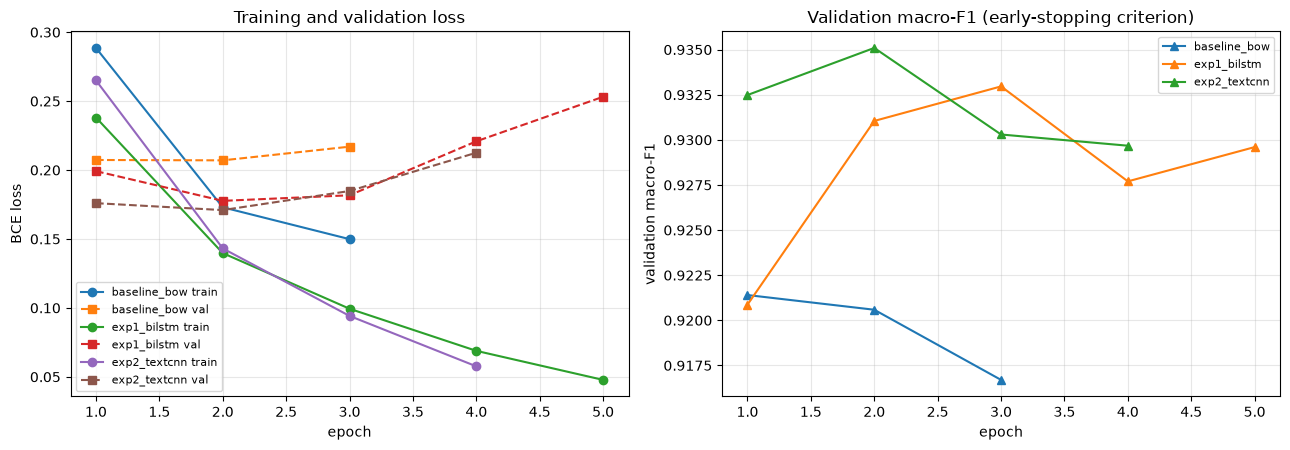

baseline_bow   epochs run 3  best val macro-F1 0.9214 at epoch 1
exp1_bilstm    epochs run 5  best val macro-F1 0.9330 at epoch 3
exp2_textcnn   epochs run 4  best val macro-F1 0.9351 at epoch 2


In [18]:
histories = json.loads((OUT_DIR / "histories.json").read_text("utf-8"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for name, h in histories.items():
    axes[0].plot(h["epoch"], h["train_loss"], marker="o", label=f"{name} train")
    axes[0].plot(h["epoch"], h["val_loss"], marker="s", ls="--", label=f"{name} val")
    axes[1].plot(h["epoch"], h["val_macro_f1"], marker="^", label=name)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Training and validation loss"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation macro-F1")
axes[1].set_title("Validation macro-F1 (early-stopping criterion)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

for name, h in histories.items():
    best = max(h["val_macro_f1"])
    print(f"{name:14s} epochs run {len(h['epoch'])}  best val macro-F1 {best:.4f} "
          f"at epoch {h['epoch'][h['val_macro_f1'].index(best)]}")

---
# Part 4 — Evaluation

Every metric in the Task 2 list, on the **full official 38,000-review test set**.

A note on how these are computed, since section 4 of the brief asks me to be able to
explain it. The bootstrap resamples test *cases* with replacement 2,000 times and takes
the 2.5th and 97.5th percentiles of the resulting distribution. It works from 2x2
contingency counts rather than calling scikit-learn per replicate, because accuracy,
macro-F1 and MCC all have closed forms in TP/FP/FN/TN — which turns 2,000 replicates
over 38,000 rows from minutes into about a second.

In [19]:
report = pd.read_csv(MEMBER_DIR / "metrics_report.csv")
preds = np.load(OUT_DIR / "test_predictions.npz")
y_true = preds["y_true"]
models = report["model"].tolist()

headline = report.set_index("model")[[
    "accuracy", "f1_macro", "roc_auc", "pr_auc", "mcc",
    "brier_score", "ece_predicted_class_confidence", "ece_positive_class",
]]
headline.round(4)

,accuracy,f1_macro,roc_auc,pr_auc,mcc,brier_score,ece_predicted_class_confidence,ece_positive_class
model,,,,,,,,
baseline_bow,0.9245,0.9245,0.9751,0.9748,0.8492,0.0572,0.0044,0.0075
exp1_bilstm,0.9334,0.9334,0.9830,0.9836,0.8671,0.0500,0.0165,0.0203
exp2_textcnn,0.9344,0.9344,0.9829,0.9835,0.8688,0.0487,0.0061,0.0064


In [20]:
detail = report.set_index("model")[[
    "precision_macro", "recall_macro", "f1_macro",
    "precision_micro", "recall_micro", "f1_micro",
    "precision_weighted", "recall_weighted", "f1_weighted",
]]
print("Precision / recall / F1 at three averagings:")
print(detail.round(4).T.to_string())
print()
print("macro and micro are identical here because the test set is exactly balanced and")
print("this is binary single-label classification — micro-F1 collapses to accuracy. On an")
print("imbalanced set they would separate, with micro tracking the majority class.")

Precision / recall / F1 at three averagings:
model               baseline_bow  exp1_bilstm  exp2_textcnn
precision_macro           0.9247       0.9337        0.9344
recall_macro              0.9245       0.9334        0.9344
f1_macro                  0.9245       0.9334        0.9344
precision_micro           0.9245       0.9334        0.9344
recall_micro              0.9245       0.9334        0.9344
f1_micro                  0.9245       0.9334        0.9344
precision_weighted        0.9247       0.9337        0.9344
recall_weighted           0.9245       0.9334        0.9344
f1_weighted               0.9245       0.9334        0.9344

macro and micro are identical here because the test set is exactly balanced and
this is binary single-label classification — micro-F1 collapses to accuracy. On an
imbalanced set they would separate, with micro tracking the majority class.


In [21]:
cis = report.set_index("model")[[
    "accuracy", "accuracy_ci95_low", "accuracy_ci95_high",
    "f1_macro", "macro_f1_ci95_low", "macro_f1_ci95_high",
    "mcc", "mcc_ci95_low", "mcc_ci95_high",
]]
print("95% bootstrap confidence intervals (2,000 replicates):")
for name in models:
    r = cis.loc[name]
    print(f"\n{name}")
    print(f"  accuracy  {r['accuracy']:.4f}  [{r['accuracy_ci95_low']:.4f}, {r['accuracy_ci95_high']:.4f}]")
    print(f"  macro-F1  {r['f1_macro']:.4f}  [{r['macro_f1_ci95_low']:.4f}, {r['macro_f1_ci95_high']:.4f}]")
    print(f"  MCC       {r['mcc']:.4f}  [{r['mcc_ci95_low']:.4f}, {r['mcc_ci95_high']:.4f}]")

95% bootstrap confidence intervals (2,000 replicates):

baseline_bow
  accuracy  0.9245  [0.9218, 0.9272]
  macro-F1  0.9245  [0.9218, 0.9271]
  MCC       0.8492  [0.8438, 0.8545]

exp1_bilstm
  accuracy  0.9334  [0.9309, 0.9358]
  macro-F1  0.9334  [0.9309, 0.9358]
  MCC       0.8671  [0.8622, 0.8719]

exp2_textcnn
  accuracy  0.9344  [0.9319, 0.9368]
  macro-F1  0.9344  [0.9319, 0.9368]
  MCC       0.8688  [0.8638, 0.8737]


## 4.1 Confusion matrices

With a balanced test set, the interesting question is whether a model's errors are symmetric or whether it leans toward one class.

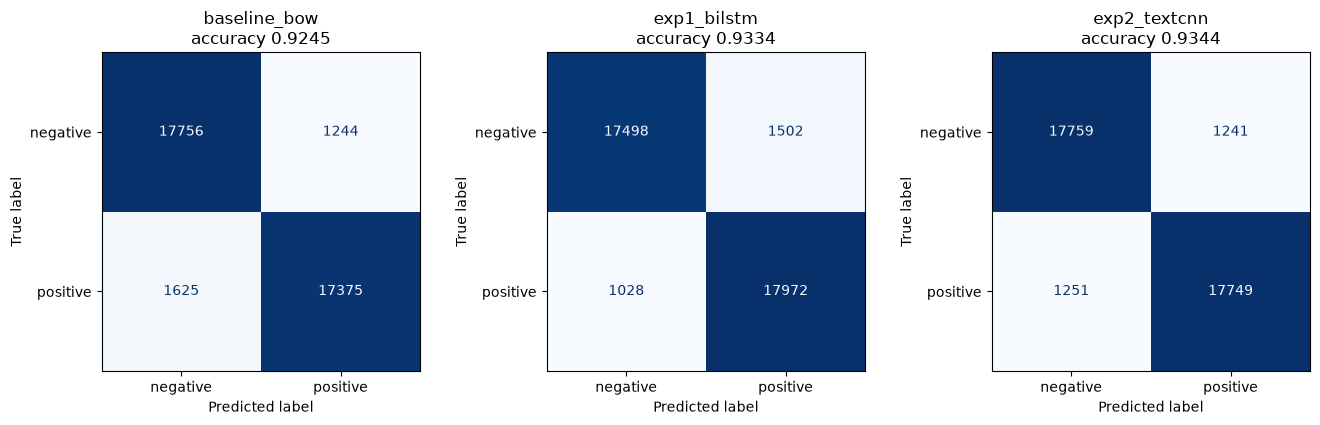

baseline_bow   false positives  1244  false negatives  1625  ratio 0.77
exp1_bilstm    false positives  1502  false negatives  1028  ratio 1.46
exp2_textcnn   false positives  1241  false negatives  1251  ratio 0.99


In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(models), figsize=(4.5 * len(models), 4.2))
for ax, name in zip(np.atleast_1d(axes), models):
    ConfusionMatrixDisplay.from_predictions(
        y_true, preds[f"pred_{name}"], display_labels=["negative", "positive"],
        ax=ax, colorbar=False, cmap="Blues", values_format="d")
    acc = report.loc[report["model"] == name, "accuracy"].iloc[0]
    ax.set_title(f"{name}\naccuracy {acc:.4f}")
plt.tight_layout(); plt.show()

for name in models:
    r = report[report["model"] == name].iloc[0]
    fp, fn = int(r["confusion_fp"]), int(r["confusion_fn"])
    print(f"{name:14s} false positives {fp:5d}  false negatives {fn:5d}  "
          f"ratio {fp / max(fn, 1):.2f}")

## 4.2 ROC and precision-recall curves

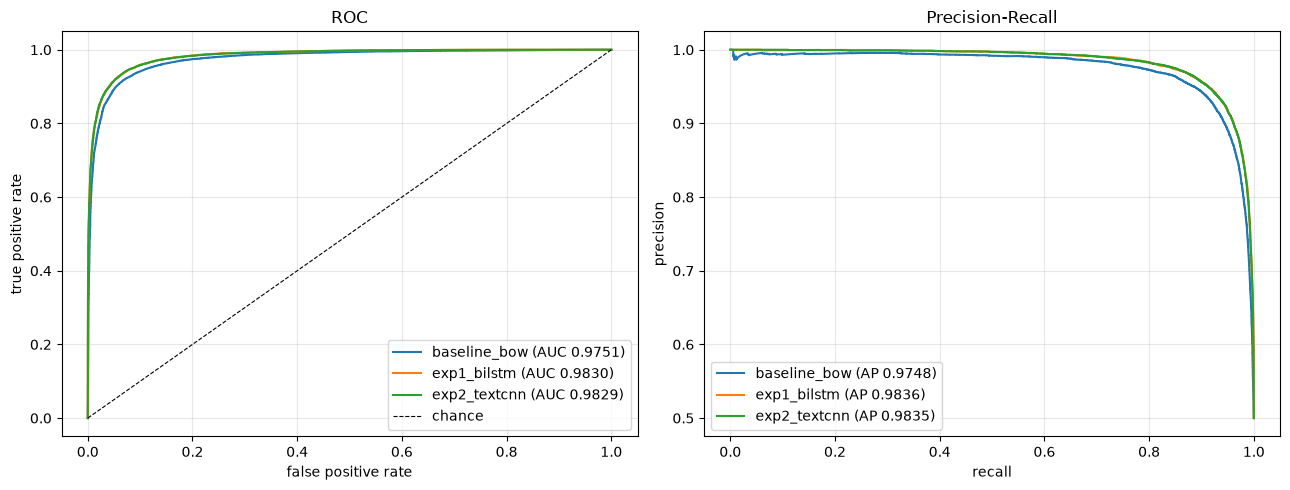

In [23]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in models:
    p = preds[f"probs_{name}"]
    fpr, tpr, _ = roc_curve(y_true, p)
    auc = report.loc[report["model"] == name, "roc_auc"].iloc[0]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {auc:.4f})")
    prec, rec, _ = precision_recall_curve(y_true, p)
    ap = report.loc[report["model"] == name, "pr_auc"].iloc[0]
    axes[1].plot(rec, prec, label=f"{name} (AP {ap:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="chance")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC"); axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall"); axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4.3 Calibration

Accuracy says how often a model is right; calibration says whether its confidence means
anything. Two numbers for it:

- **Brier score** — mean squared error of the predicted probability. Lower is better,
  and it rewards being both accurate *and* honestly uncertain.
- **Expected calibration error** — bin predictions by confidence, then average
  `|accuracy - confidence|` weighted by bin size. A model at 99% confidence that is
  right 80% of the time has poor ECE regardless of its accuracy.

These come apart from accuracy, which is why both are on the required list.

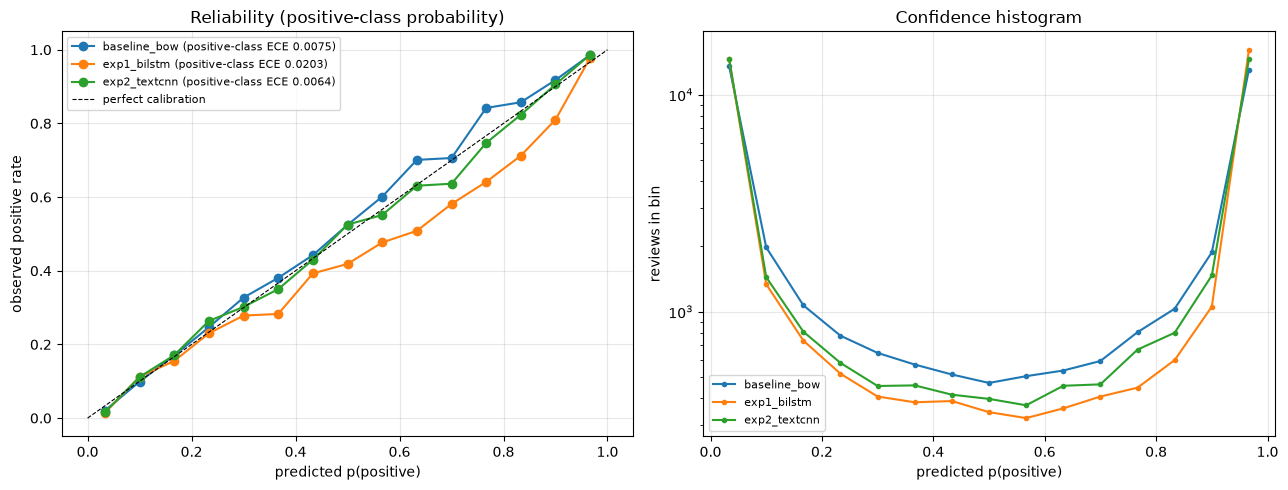

              brier_score  ece_predicted_class_confidence  ece_positive_class
model                                                                        
baseline_bow       0.0572                          0.0044              0.0075
exp1_bilstm        0.0500                          0.0165              0.0203
exp2_textcnn       0.0487                          0.0061              0.0064


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in models:
    centres, accs, counts = M.reliability_bins(
        y_true, preds[f"probs_{name}"], CFG["eval"]["calibration_bins"])
    # The positive-class ECE, because this axis bins p(positive) over [0, 1]. The
    # confidence ECE bins the predicted class over [0.5, 1] and would be a number from
    # a different measurement wearing this plot's label.
    ece = report.loc[report["model"] == name, "ece_positive_class"].iloc[0]
    ok = ~np.isnan(accs)
    axes[0].plot(centres[ok], accs[ok], marker="o",
                 label=f"{name} (positive-class ECE {ece:.4f})")
    axes[1].plot(centres, counts, marker=".", label=name)
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="perfect calibration")
axes[0].set_xlabel("predicted p(positive)"); axes[0].set_ylabel("observed positive rate")
axes[0].set_title("Reliability (positive-class probability)"); axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("predicted p(positive)"); axes[1].set_ylabel("reviews in bin")
axes[1].set_yscale("log"); axes[1].set_title("Confidence histogram")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(report.set_index("model")[["brier_score", "ece_predicted_class_confidence",
                                 "ece_positive_class"]].round(4).to_string())

## 4.4 Paired McNemar tests

The confidence intervals above are *unpaired* — they treat the three models as
independent samples, which they are not: all three are scored on identical test rows.
McNemar uses that pairing. It looks only at the **discordant** cases, where exactly one
of the two models is right, and asks whether the split between them is more lopsided
than a coin flip.

This is the test that answers "is this experimental model genuinely better than my
baseline, or did it just get luckier on the same 38,000 reviews?"

In [25]:
mc = pd.read_csv(OUT_DIR / "mcnemar_tests.csv")
for _, r in mc.iterrows():
    print(f"{r['model_a']} vs {r['model_b']}")
    print(f"  both correct        {r['both_correct']:6d}")
    print(f"  only {r['model_a']:<14s} {r['only_a_correct']:6d}")
    print(f"  only {r['model_b']:<14s} {r['only_b_correct']:6d}")
    print(f"  both wrong          {r['both_wrong']:6d}")
    print(f"  {r['test']}: statistic {r['statistic']:.2f}, p = {r['p_value']:.3e}")
    verdict = "significant at 0.05" if r["p_value"] < 0.05 else "NOT significant at 0.05"
    better = r["model_b"] if r["only_b_correct"] > r["only_a_correct"] else r["model_a"]
    print(f"  -> {verdict}; more discordant wins go to {better}\n")

baseline_bow vs exp1_bilstm
  both correct         34155
  only baseline_bow      976
  only exp1_bilstm      1315
  both wrong            1554
  chi-square (continuity corrected): statistic 49.87, p = 1.646e-12
  -> significant at 0.05; more discordant wins go to exp1_bilstm

baseline_bow vs exp2_textcnn
  both correct         34199
  only baseline_bow      932
  only exp2_textcnn     1309
  both wrong            1560
  chi-square (continuity corrected): statistic 63.09, p = 1.979e-15
  -> significant at 0.05; more discordant wins go to exp2_textcnn



## 4.5 Robustness: macro-F1 per data slice

Overall accuracy hides where a model fails. The slices are computed from the **raw** review text before cleaning, because cleaning destroys exactly the signals some of the slices are about — capitalisation and punctuation. Slices with fewer than 200 reviews are dropped, since macro-F1 on a handful of rows swings too much to support a conclusion.

                            baseline_bow  exp1_bilstm  exp2_textcnn  n_reviews
label                                                                         
exclamations = has_exclaim        0.9340       0.9440        0.9433      17636
exclamations = no_exclaim         0.9120       0.9206        0.9229      20364
has_negation = negation           0.9167       0.9289        0.9291      28843
has_negation = no_negation        0.9160       0.9185        0.9207       9157
length_bucket = long              0.9228       0.9280        0.9271      12845
length_bucket = medium            0.9262       0.9355        0.9366      12241
length_bucket = short             0.9202       0.9336        0.9360      12914
shouty = normal_caps              0.9243       0.9331        0.9339      37101
shouty = shouty_caps              0.9303       0.9455        0.9558        899


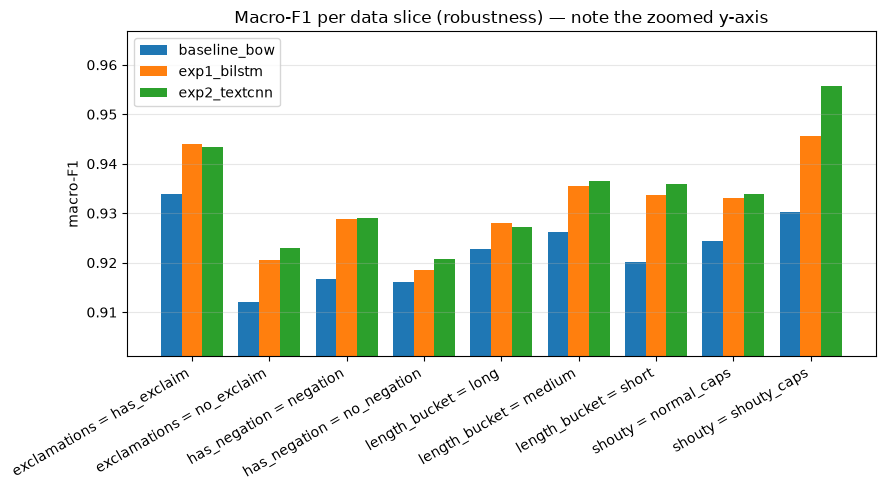

In [26]:
sl = pd.read_csv(OUT_DIR / "slice_metrics.csv")
sl["label"] = sl["slice_family"] + " = " + sl["slice"]
pivot = sl.pivot_table(index="label", columns="model", values="macro_f1")
counts = sl.groupby("label")["n"].first()
out = pivot.join(counts.rename("n_reviews"))
print(out.round(4).to_string())

order = sorted(pivot.index)
fig, ax = plt.subplots(figsize=(max(9, 0.9 * len(order)), 5))
width = 0.8 / len(models)
x = np.arange(len(order))
for i, name in enumerate(models):
    ax.bar(x + i * width, pivot.loc[order, name], width, label=name)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("macro-F1")
# Zoom to the data range: every value sits in a ~0.04 band, so a 0-1 axis would draw
# nine identical bars and hide the effect.
lo, hi = sl["macro_f1"].min(), sl["macro_f1"].max()
pad = (hi - lo) * 0.25
ax.set_ylim(lo - pad, hi + pad)
ax.set_title("Macro-F1 per data slice (robustness) — note the zoomed y-axis")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

In [27]:
print("Spread between a model's best and worst slice — a robustness summary:")
for name in models:
    s = sl[sl["model"] == name]
    lo, hi = s.loc[s["macro_f1"].idxmin()], s.loc[s["macro_f1"].idxmax()]
    print(f"  {name:14s} worst {lo['slice_family']}={lo['slice']} {lo['macro_f1']:.4f}  |  "
          f"best {hi['slice_family']}={hi['slice']} {hi['macro_f1']:.4f}  |  "
          f"spread {hi['macro_f1'] - lo['macro_f1']:.4f}")

Spread between a model's best and worst slice — a robustness summary:
  baseline_bow   worst exclamations=no_exclaim 0.9120  |  best exclamations=has_exclaim 0.9340  |  spread 0.0220
  exp1_bilstm    worst has_negation=no_negation 0.9185  |  best shouty=shouty_caps 0.9455  |  spread 0.0271
  exp2_textcnn   worst has_negation=no_negation 0.9207  |  best shouty=shouty_caps 0.9558  |  spread 0.0352


## 4.6 Cost: parameters, time, throughput, memory

Section 2.2.5 asks for the exact hardware per model, which is recorded in the `hardware` column.

In [28]:
cost = report.set_index("model")[[
    "parameter_count", "epochs_run", "training_seconds",
    "examples_per_sec", "peak_memory_mb", "hardware",
]]
cost.assign(training_minutes=(cost["training_seconds"] / 60).round(1)).round(1)

,parameter_count,epochs_run,training_seconds,examples_per_sec,peak_memory_mb,hardware,training_minutes
model,,,,,,,
baseline_bow,3873281,3,25.8,11609.9,60.0,Apple M4 integrated GPU via Apple MPS,0.4
exp1_bilstm,6605953,5,2318.6,215.6,102.4,Apple M4 integrated GPU via Apple MPS,38.6
exp2_textcnn,5087745,4,211.1,1894.8,79.1,Apple M4 integrated GPU via Apple MPS,3.5


---
# Part 5 — Manual error review (20 errors)

Section 2.2.4 requires 20 errors from my own model in four buckets: 5 confident false
positives, 5 confident false negatives, 5 near-threshold errors, and 5 from a specific
slice. Each gets an error type and one **testable** fix — testable meaning the fix
names the experiment that would confirm or refute the diagnosis, not just a direction
to move in.

The full write-up with every review text is in `failure_analysis.md`; the table below
is the selection with its diagnostics.

In [29]:
best_model = report.loc[report["f1_macro"].idxmax(), "model"]
err = pd.read_csv(OUT_DIR / f"error_review_{best_model}.csv")
summary = json.loads((OUT_DIR / "error_review_summary.json").read_text("utf-8"))

print(f"model reviewed : {summary['model_reviewed']} (highest macro-F1)")
print(f"total errors   : {summary['n_errors']:,} of {len(y_true):,} "
      f"({summary['error_rate']:.2%})")
print(f"worst slice    : {summary['worst_slice']['slice_family']} = "
      f"{summary['worst_slice']['slice']} "
      f"(error rate {summary['worst_slice']['error_rate']:.3f})")
print(f"buckets        : {summary['bucket_counts']}")

err[["bucket", "test_index", "true_label", "predicted_prob_positive",
     "n_tokens", "oov_rate", "has_negation", "truncated", "suggested_error_type"]]

model reviewed : exp2_textcnn (highest macro-F1)
total errors   : 2,492 of 38,000 (6.56%)
worst slice    : exclamations = no_exclaim (error rate 0.075)
buckets        : {'confident false positive': 5, 'confident false negative': 5, 'near-threshold error': 5, 'slice-specific failure (exclamations=no_exclaim)': 5}


,bucket,test_index,true_label,predicted_prob_positive,n_tokens,oov_rate,has_negation,truncated,suggested_error_type
0,confident false positive,29330,0,0.999716,18,0.000000,False,False,"insufficient evidence — very short review, lit..."
1,confident false positive,11429,0,0.999415,4,0.000000,False,False,"insufficient evidence — very short review, lit..."
2,confident false positive,7661,0,0.999135,24,0.041667,False,False,mixed sentiment — review contains both praise ...
3,confident false positive,37451,0,0.999041,39,0.025641,True,False,negation scope — polarity word present but neg...
4,confident false positive,12480,0,0.999008,11,0.000000,False,False,"insufficient evidence — very short review, lit..."
5,confident false negative,21780,1,0.000195,434,0.012000,True,True,truncation — verdict may fall outside the firs...
6,confident false negative,22807,1,0.000252,48,0.000000,True,False,negation scope — polarity word present but neg...
7,confident false negative,30793,1,0.000485,47,0.000000,True,False,negation scope — polarity word present but neg...
8,confident false negative,26683,1,0.000524,13,0.000000,True,False,negation scope — polarity word present but neg...
9,confident false negative,2285,1,0.000584,28,0.000000,True,False,negation scope — polarity word present but neg...


In [30]:
print("Error types across the 20 reviewed:")
print(err["suggested_error_type"].value_counts().to_string())
print()
for bucket in err["bucket"].unique():
    sub = err[err["bucket"] == bucket]
    print(f"\n{'=' * 95}\n{bucket.upper()}\n{'=' * 95}")
    for _, r in sub.head(2).iterrows():
        print(f"\n[index {r['test_index']}] true="
              f"{'positive' if r['true_label'] == 1 else 'negative'}  "
              f"p(positive)={r['predicted_prob_positive']:.4f}  "
              f"tokens={r['n_tokens']}  negation={r['has_negation']}")
        print(f"  type : {r['suggested_error_type']}")
        print(f"  fix  : {r['proposed_testable_fix']}")
        print(f"  text : {r['review_text'][:400]}")

Error types across the 20 reviewed:
suggested_error_type
negation scope — polarity word present but negated nearby                 10
insufficient evidence — very short review, little lexical signal           4
mixed sentiment — review contains both praise and complaint                4
truncation — verdict may fall outside the first max_len tokens             1
punctuation signal stripped — emphatic punctuation removed in cleaning     1


CONFIDENT FALSE POSITIVE

[index 29330] true=negative  p(positive)=0.9997  tokens=18  negation=False
  type : insufficient evidence — very short review, little lexical signal
  fix  : Check whether accuracy on the shortest length decile improves when the classifier abstains below a confidence floor.
  text : Wow love the place and everything is very clean and new!\n\nGreat place to come and relax worth a try!\n\nCheers,\n\nEric Van Nguyen\nVisited April 2012

[index 11429] true=negative  p(positive)=0.9994  tokens=4  negation=False
  type : insuffici

---
# Part 6 — Comparative analysis

Section 2.3 asks me to compare my own three models, then note strengths, weaknesses and
limitations, and say what I would do next. The team-level comparison against Tejas's
models goes in the combined report.

In [31]:
compare = report.set_index("model")[[
    "accuracy", "f1_macro", "roc_auc", "pr_auc", "mcc",
    "brier_score", "ece_predicted_class_confidence", "ece_positive_class",
    "parameter_count", "training_seconds", "examples_per_sec",
]].copy()
compare["training_minutes"] = (compare.pop("training_seconds") / 60).round(1)

base = compare.loc[[m for m in models if m.startswith("baseline")][0]]
delta = (compare[["accuracy", "f1_macro", "mcc"]] - base[["accuracy", "f1_macro", "mcc"]])
print("Absolute metrics:")
print(compare.round(4).to_string())
print("\nChange vs the baseline (positive = better than baseline):")
print(delta.round(4).to_string())

Absolute metrics:
              accuracy  f1_macro  roc_auc  pr_auc     mcc  brier_score  ece_predicted_class_confidence  ece_positive_class  parameter_count  examples_per_sec  training_minutes
model                                                                                                                                                                          
baseline_bow    0.9245    0.9245   0.9751  0.9748  0.8492       0.0572                          0.0044              0.0075          3873281        11609.9332               0.4
exp1_bilstm     0.9334    0.9334   0.9830  0.9836  0.8671       0.0500                          0.0165              0.0203          6605953          215.6489              38.6
exp2_textcnn    0.9344    0.9344   0.9829  0.9835  0.8688       0.0487                          0.0061              0.0064          5087745         1894.8045               3.5

Change vs the baseline (positive = better than baseline):
              accuracy  f1_macro     mcc
mo

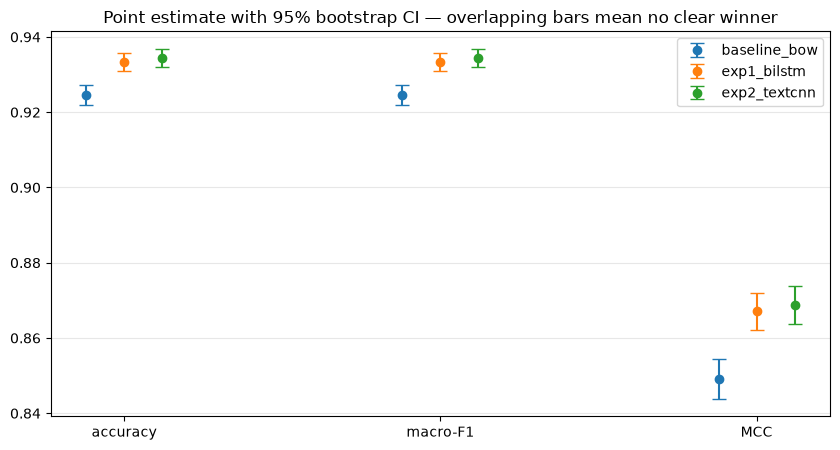

In [32]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
names = ["accuracy", "macro_f1", "mcc"]
cols = {"accuracy": "accuracy", "macro_f1": "f1_macro", "mcc": "mcc"}
x = np.arange(len(names))
for i, name in enumerate(models):
    r = report[report["model"] == name].iloc[0]
    vals = np.array([r[cols[m]] for m in names])
    lo = np.array([r[f"{m}_ci95_low"] for m in names])
    hi = np.array([r[f"{m}_ci95_high"] for m in names])
    ax.errorbar(x + i * 0.12 - 0.12, vals, yerr=np.vstack([vals - lo, hi - vals]),
                fmt="o", capsize=5, label=name)
ax.set_xticks(x); ax.set_xticklabels(["accuracy", "macro-F1", "MCC"])
ax.set_title("Point estimate with 95% bootstrap CI — overlapping bars mean no clear winner")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

The interpretation, the limitations and the next experiments are written up in
`results.md`, which is the document I will have open for the viva.

**Compliance check for section 2:**

- Review length, class distribution and class balance analysed (1.1, 1.3).
- Missing and malformed entries handled — checked, and the corpus was clean (1.2).
- Lowercasing, punctuation removal, stopword removal and stemming all applied, with the
  negation retention decision demonstrated rather than asserted (1.4).
- Tokenised, with a from-scratch vocabulary built on the training split only (1.5).
- Embeddings learned from scratch; no pretrained embeddings or pretrained LM anywhere (1.6).
- Three of my own models: one baseline, two experimental, differing in both architecture
  and hyperparameters (Part 2).
- Every required metric reported per model (Part 4).
- 20 errors reviewed in the required 5/5/5/5 split, each with an error type and a
  testable fix (Part 5).
- Exact CPU/GPU recorded per model (4.6).
- Comparative analysis with strengths, weaknesses, limitations and future work (Part 6,
  `results.md`).